### 1. Imports

In [35]:
# =========================================================
# IMPORTS
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

### 2. Configuración

In [36]:
# =========================================================
# CONFIGURATION
# =========================================================

pd.set_option('display.max_columns', None)

RANDOM_STATE = 42

### 3. Carga dataset

In [37]:
# =========================================================
# LOAD FEATURED DATASET
# =========================================================

path = "../data/gold/featured_dataset_v1.parquet"

df = pd.read_parquet(path)

print(df.shape)

df.head()

(140256, 61)


,Temperatura,Temperatura màxima,Temperatura mínima,Humitat relativa,Humitat relativa màxima,Humitat relativa mínima,Pressió atmosfèrica,Pressió atmosfèrica mínima,Velocitat del vent a 6 m (esc.),Ratxa màxima del vent a 6 m,Precipitació,Precipitació màxima en 1 minut,Irradiància solar global,wind_u,wind_v,sst,sst_original,wave_height,wave_height_h13,wave_period_mean,wave_period_tm02,wave_peak_period,wave_max_period,wave_direction,wave_peak_direction,wave_angular_spread,sst_roll_6h,sst_roll_24h,sst_delta_3h,sst_delta_24h,temperature,wind_direction_deg,wind_avg,wind_min,wind_max,month,hour,is_operational_hour,wind_data_available,valid_wind_observation,operational_gap,day_of_year,season,hour_sin,hour_cos,doy_sin,doy_cos,pressure_tendency_3h,pressure_tendency_6h,air_temp_combined,coastal_inland_temp_diff,land_sea_temp_gradient,thermal_wind_flag,thermal_event,sailable_wind,daily_temp_range,solar_roll_3h,solar_roll_6h,sst_climatology,sst_anomaly,solar_gradient_interaction
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2010-01-01 00:00:00,11.80,12.1,11.3,48.0,49.0,46.0,989.5,989.0,7.40,16.900000,0.2,0.2,0.0,-1.852812,-7.164292,14.0,14.0,2.05,1.84,5.55,5.14,6.65,6.78,210.0,210.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0,0,1,1,0.000000,1.000000,0.017213,0.999852,NaN,NaN,11.80,NaN,-2.20,False,0,0,3.725001,NaN,NaN,NaN,NaN,-0.0
2010-01-01 01:00:00,10.90,11.3,10.3,49.0,51.0,47.0,990.0,989.0,7.80,17.200001,0.0,0.0,0.0,-0.611981,-7.775955,14.0,14.0,1.88,1.78,5.53,5.06,7.13,7.00,213.0,205.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,0,0,1,1,0.258819,0.965926,0.017213,0.999852,NaN,NaN,10.90,NaN,-3.10,False,0,0,3.725001,NaN,NaN,NaN,NaN,-0.0
2010-01-01 02:00:00,10.30,10.3,10.2,49.5,51.0,48.0,990.0,989.0,7.95,15.900000,0.0,0.0,0.0,-0.208105,-7.947276,14.0,14.0,1.95,1.84,5.76,5.02,7.13,7.67,217.0,219.0,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2,0,0,0,0,1,1,0.500000,0.866025,0.017213,0.999852,NaN,NaN,10.30,NaN,-3.70,False,0,0,3.725001,0.0,NaN,NaN,NaN,-0.0
2010-01-01 03:00:00,9.85,10.2,9.6,47.0,48.0,47.0,990.5,990.0,8.00,16.299999,0.0,0.0,0.0,-0.627673,-7.975338,14.0,14.0,2.24,2.08,6.10,5.53,7.68,8.55,214.0,213.0,24.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1,3,0,0,0,0,1,1,0.707107,0.707107,0.017213,0.999852,1.0,NaN,9.85,NaN,-4.15,False,0,0,3.725001,0.0,NaN,NaN,NaN,-0.0
2010-01-01 04:00:00,9.50,9.6,9.4,46.0,47.0,45.0,991.0,990.0,7.15,15.900000,0.0,0.0,0.0,-1.241584,-7.041375,14.0,14.0,2.62,2.37,6.46,5.85,7.67,8.19,214.0,212.0,23.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1,4,0,0,0,0,1,1,0.866025,0.500000,0.017213,0.999852,1.0,NaN,9.50,NaN,-4.50,False,0,0,3.725001,0.0,NaN,NaN,NaN,-0.0


### 4. Crear Daily Dataset

In [39]:
# =========================================================
# DAILY TARGET
# =========================================================

daily_target = (
    df["thermal_wind_flag"]
    .resample("D")
    .max()
    .astype(int)
    .rename("daily_target")
)

daily_target.value_counts()

daily_target
0    4555
1    1289
Name: count, dtype: int64

### 5. Crear Features Diarias

In [ ]:
# Meteorología terrestre

daily_features = pd.DataFrame(index=daily_target.index)

daily_features["temp_mean"] = df["Temperatura"].resample("D").mean()

daily_features["temp_max"] = df["Temperatura"].resample("D").max()

daily_features["temp_min"] = df["Temperatura"].resample("D").min()

daily_features["humidity_mean"] = (
    df["Humitat relativa"]
    .resample("D")
    .mean()
)

daily_features["pressure_mean"] = (
    df["Pressió atmosfèrica"]
    .resample("D")
    .mean()
)

In [ ]:
# Radiación

daily_features["solar_total"] = (
    df["Irradiància solar global"]
    .resample("D")
    .sum()
)

daily_features["solar_max"] = (
    df["Irradiància solar global"]
    .resample("D")
    .max()
)

In [ ]:
# SST

daily_features["sst_mean"] = (
    df["sst"]
    .resample("D")
    .mean()
)

daily_features["sst_anomaly_mean"] = (
    df["sst_anomaly"]
    .resample("D")
    .mean()
)

In [ ]:
# Gradientes

daily_features["land_sea_temp_gradient"] = (
    df["land_sea_temp_gradient"]
    .resample("D")
    .mean()
)

daily_features["coastal_inland_temp_diff"] = (
    df["coastal_inland_temp_diff"]
    .resample("D")
    .mean()
)

In [ ]:
#Features temporales

daily_features["month"] = daily_features.index.month

daily_features["day_of_year"] = daily_features.index.dayofyear

### 6. Dataset Final

In [48]:
daily_df = pd.concat(
    [daily_features, daily_target],
    axis=1
)

daily_df.head()

,temp_mean,temp_max,temp_min,humidity_mean,pressure_mean,solar_total,solar_max,sst_mean,sst_anomaly_mean,land_sea_temp_gradient,coastal_inland_temp_diff,month,day_of_year,daily_target
datetime,,,,,,,,,,,,,,
2010-01-01,11.004167,13.05,9.299999,45.208332,996.500000,5121.0,1141.0,13.937500,-0.137500,-2.859673,-0.321428,1,1,0
2010-01-02,9.385417,11.25,6.950000,62.604168,1011.979187,3259.0,787.0,13.833333,-0.067034,-4.237500,-0.918182,1,2,0
2010-01-03,10.504167,12.65,7.200000,71.104164,1012.000000,3504.0,772.0,13.837500,-0.036806,-3.227083,-0.463636,1,3,0
2010-01-04,10.191667,11.00,9.250000,79.041664,1004.666687,1289.0,262.0,13.795833,-0.062718,-3.473958,-0.568182,1,4,0
2010-01-05,10.604167,11.90,9.650000,79.770836,995.541687,1103.0,326.0,13.679167,-0.152296,-2.903125,-0.750000,1,5,0


### 7. Missing Values

In [49]:
daily_df = daily_df.fillna(
    daily_df.median(numeric_only=True)
)

### 8. Train / Validation / Test

In [50]:
train = daily_df.loc[:'2021-12-31']

valid = daily_df.loc['2022-01-01':'2023-12-31']

test = daily_df.loc['2024-01-01':]

### 9. Definir X e y

In [51]:
TARGET = "daily_target"

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]

X_valid = valid.drop(columns=[TARGET])
y_valid = valid[TARGET]

X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]

### 10. Baseline Dummy

In [52]:
from sklearn.dummy import DummyClassifier

In [53]:
dummy = DummyClassifier(
    strategy="most_frequent"
)

dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

### 11. Random Forest Baseline

In [57]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [58]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

### 12. Evaluación

- Accuracy
- Precision
- Recall
- F1
- ROC-AUC

In [59]:
# =========================================================
# PREDICTIONS
# =========================================================

y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:, 1]

In [60]:
# =========================================================
# EVALUATION METRICS
# =========================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("RANDOM FOREST PERFORMANCE")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

RANDOM FOREST PERFORMANCE
Accuracy : 0.7223
Precision: 0.4425
Recall   : 0.7471
F1 Score : 0.5558
ROC-AUC  : 0.8020


In [61]:
# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Sea Breeze",
            "Sea Breeze"
        ]
    )
)

               precision    recall  f1-score   support

No Sea Breeze       0.90      0.71      0.80       561
   Sea Breeze       0.44      0.75      0.56       170

     accuracy                           0.72       731
    macro avg       0.67      0.73      0.68       731
 weighted avg       0.80      0.72      0.74       731



### 13. Confusion Matrix

#### Confusion Matrix

Visualizamos los aciertos y errores del modelo.

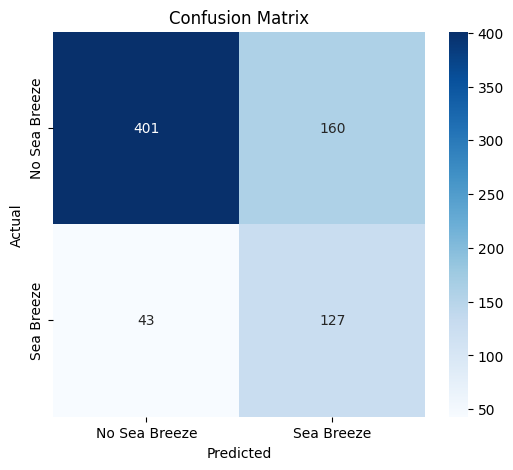

In [62]:
# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Sea Breeze",
        "Sea Breeze"
    ],
    yticklabels=[
        "No Sea Breeze",
        "Sea Breeze"
    ]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

### 14. ROC Curve

#### ROC Curve

Capacidad del modelo para separar días con Sea Breeze
de días sin Sea Breeze.

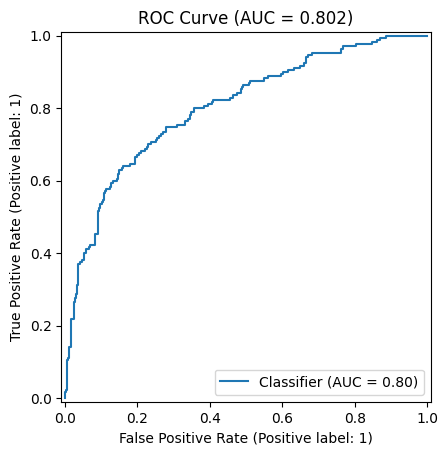

In [63]:
# =========================================================
# ROC CURVE
# =========================================================

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title(
    f"ROC Curve (AUC = {roc_auc:.3f})"
)

plt.show()

#### Feature Importance

Identificamos las variables más importantes para explicar
la aparición de Sea Breeze.

In [64]:
# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)

importance = (
    importance
    .sort_values(
        ascending=False
    )
)

importance.head(20)

coastal_inland_temp_diff    0.198321
solar_max                   0.122661
solar_total                 0.117033
humidity_mean               0.068081
day_of_year                 0.068033
temp_max                    0.065380
land_sea_temp_gradient      0.064023
sst_anomaly_mean            0.063980
pressure_mean               0.053573
temp_mean                   0.052250
sst_mean                    0.052216
temp_min                    0.049235
month                       0.025214
dtype: float64

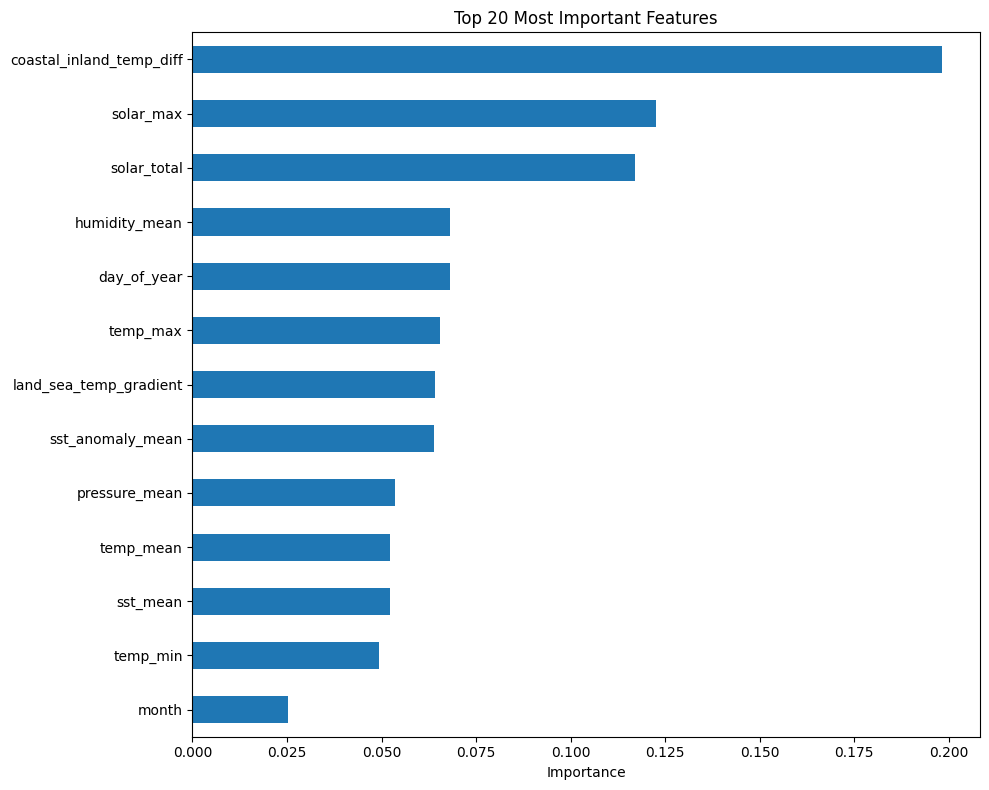

In [65]:
# =========================================================
# TOP 20 FEATURES
# =========================================================

plt.figure(figsize=(10,8))

importance.head(20).sort_values().plot.barh()

plt.title(
    "Top 20 Most Important Features"
)

plt.xlabel(
    "Importance"
)

plt.tight_layout()

plt.show()

In [66]:
# =========================================================
# FULL FEATURE RANKING
# =========================================================

feature_ranking = (
    importance
    .reset_index()
)

feature_ranking.columns = [
    "feature",
    "importance"
]

feature_ranking.head(30)

,feature,importance
0,coastal_inland_temp_diff,0.198321
1,solar_max,0.122661
2,solar_total,0.117033
3,humidity_mean,0.068081
4,day_of_year,0.068033
5,temp_max,0.065380
6,land_sea_temp_gradient,0.064023
7,sst_anomaly_mean,0.063980
8,pressure_mean,0.053573
9,temp_mean,0.052250


In [67]:
# =========================================================
# EXPORT FEATURE IMPORTANCE
# =========================================================

feature_ranking.to_csv(
    "../reports/feature_importance_daily_model.csv",
    index=False
)

print(
    "Feature importance exported successfully."
)

Feature importance exported successfully.


In [29]:
daily_target = (
    df["thermal_wind_flag"]
    .resample("D")
    .max()
    .astype(int)
)

print(daily_target.value_counts())

print()

print(
    daily_target.value_counts(normalize=True) * 100
)

thermal_wind_flag
0    4555
1    1289
Name: count, dtype: int64

thermal_wind_flag
0    77.94319
1    22.05681
Name: proportion, dtype: float64


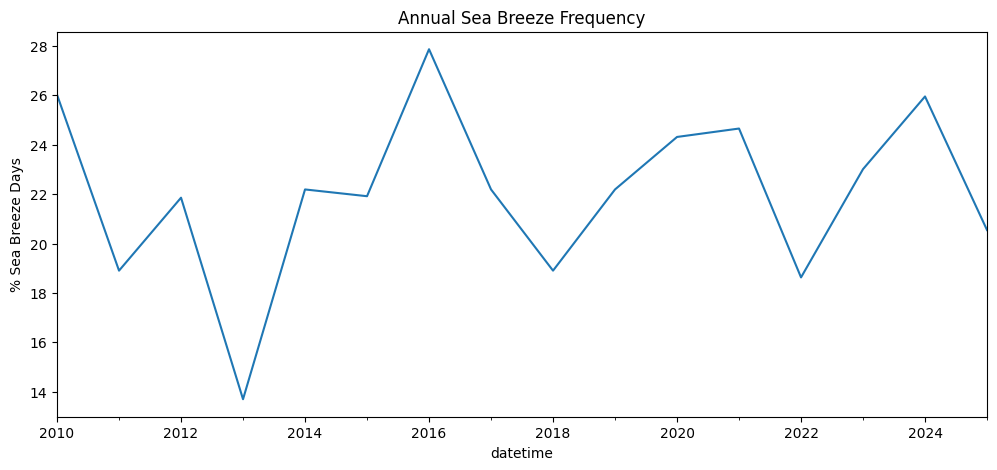

In [31]:
daily_target = (
    df["thermal_wind_flag"]
    .resample("D")
    .max()
    .astype(int)
)

annual_counts = (
    daily_target
    .resample("YE")
    .mean()
    * 100
)

annual_counts.plot(
    figsize=(12,5)
)

plt.ylabel("% Sea Breeze Days")
plt.title("Annual Sea Breeze Frequency")

plt.show()